In [2]:
import pyvista as pv
import imageio
import glob
from tqdm import tqdm
import os.path as osp
import os
from IPython.display import Image
import numpy as np

def max_solid_id(folder_path):
    txt_file = next(
        f for f in os.listdir(folder_path)
        if f.endswith('.txt') and osp.isfile(osp.join(folder_path, f))
    )
    with open(osp.join(folder_path, txt_file)) as f:
        return max([int(x) for line in f for x in line.split()])

def get_plotter(window_width,aspect_ratio):
    
    # Prepare plotter (off-screen for headless environments)
    
    window_height = int(window_width * aspect_ratio[1] / aspect_ratio[0])

    # Add extra width for the color bar (e.g., 75% more)
    window_width_with_bar = int(window_width * 1.75)

    plotter = pv.Plotter(
        off_screen=True,
        window_size=(window_width_with_bar, window_height)
    )
    plotter.background_color = "white"
    plotter.camera_position = 'xy'
    plotter.set_focus((aspect_ratio[0]/2, aspect_ratio[1]/2, 0))
    plotter.set_position((aspect_ratio[0]/2, aspect_ratio[1]/2, 1))
    plotter.camera.SetParallelScale(aspect_ratio[1]/2)  # half of y-range
    
    return plotter
    
def animation(folder,field_name,aspect_ratio,window_width=300):
    
    # read the simulation data
    vtk_files = sorted(glob.glob(osp.join(folder, "step_*.vtk")))
    
    # find the id where the solid ends and fluid starts
    max_id = max_solid_id(folder)
    
    
    magnitudes = []
    for file in tqdm(vtk_files,desc=f'Find min-max of {field_name}'):
        mesh = pv.read(file)
        fluid = mesh.extract_points(mesh.point_data["id"] > max_id)
        value = fluid.point_data[field_name]
        magnitudes += [np.linalg.norm(value, axis=1)] if value.shape[1] > 1 else [value]
    all_mags = np.concatenate(magnitudes)
    vmin, vmax = all_mags.min(), all_mags.max()

    plotter = get_plotter(window_width=window_width, aspect_ratio=aspect_ratio)

    # Output image list
    frames = []

    # Loop over VTK files and generate frames
    for file in tqdm(vtk_files,desc='Create frames'):
        mesh = pv.read(file)
        
        value = mesh.point_data[field_name]
        if value.shape[1] > 1:
            mesh.point_data[f'|{field_name}|'] = np.linalg.norm(value, axis=1)
        
        scalars = field_name if value.shape[1] == 1 else f'|{field_name}|'
        
        
        fluid = mesh.extract_points(mesh.point_data["id"] > max_id)
        plotter.clear()
        plotter.add_mesh(
            fluid,
            scalars = scalars,
            show_edges=False,
            cmap="jet",
            clim=[vmin,vmax],
            scalar_bar_args={
                "title": scalars,
                "vertical": True,
                "position_x": 0.85,  # move to the right (0.0 = left, 1.0 = right edge)
                "position_y": 0.1,   # vertical position (0.0 = bottom, 1.0 = top)
                "width": 0.04,       # width of the color bar
                "height": 0.8        # height of the color bar
            },
            point_size=5.0,
            render_points_as_spheres=True,
        )
        
        solid = mesh.extract_points(mesh.point_data["id"] <= max_id)
        plotter.add_mesh(
            solid,
            color="black",
            point_size=5.0,
            render_points_as_spheres=True,
        )
        
        
        img = plotter.screenshot(return_img=True)
        frames.append(img)
    
    return frames

Create frames: 100%|██████████| 51/51 [00:07<00:00,  6.67it/s]


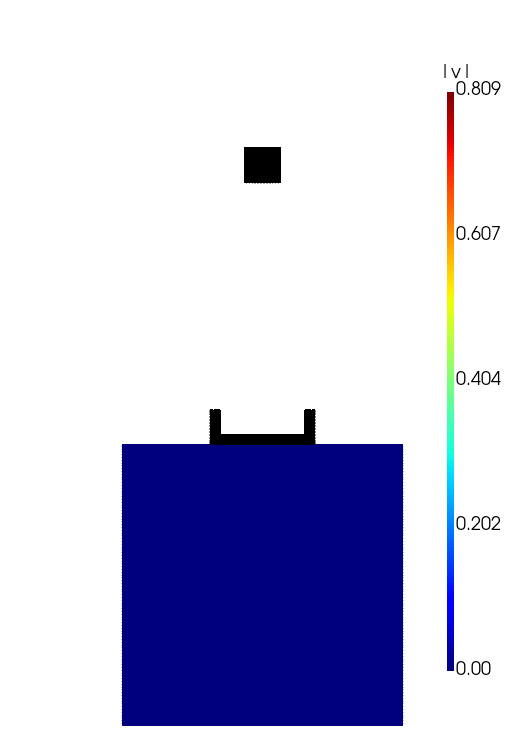

In [4]:
folder = "drop_box_on_boat/d=0.3"
#folder = "drop_boat/boat_t=10,0_rho=2000"
#folder = "drop_box/rho=7850_d=0.30_Lobj=0.025"
#folder = "drop_box/rho=2000_d=0.30_Lobj=0.050"
#folder = "drop_box/rho=7850_d=0.30_Lobj=0.050"

dt = 0.01
L = 0.2

frames = animation(folder,'v',aspect_ratio=(L,2.5*L))
imageio.mimsave(f"{folder}/animation.gif", frames, fps=int(1/dt))
imageio.imwrite(f"{folder}/frame_050.png", frames[50])
Image(filename=f"{folder}/animation.gif")

In [ ]:
for folder_name in os.listdir('drop_boat'):
    folder = osp.join('drop_boat',folder_name)
    frames = animation(folder,'v',aspect_ratio=(L,2.5*L))
    imageio.mimsave(f"{folder}/animation.gif", frames, fps=int(1/dt))
    imageio.imwrite(f"{folder}/frame_050.png", frames[50])

Create frames: 100%|██████████| 101/101 [00:15<00:00,  6.53it/s]
